Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°2 - Opcional**
## **Tema**: Simulated Annealing

Arnedo Emmanuel - 52304  
Arnedo Mateo - 53813  
Zelarayan Camila - 57261

## Ejercicio 1

Completamos las tres partes que faltaban (marcadas con `# COMPLETADO`):

- **Aceptar una solución peor.** Si el número al azar es menor que la probabilidad `p`, la solución peor pasa a ser la actual. Es lo que le permite al algoritmo salir de un óptimo local.
- **Temperatura.** Usamos el enfriamiento exponencial $T = T_0\,e^{-\mu t}$, donde $t$ es la iteración. La temperatura baja rápido al principio y cada vez más despacio, y nunca llega a cero.
- **Punto de exploración.** Elegimos una dirección al azar (un vector de largo 1, con todas las direcciones igual de probables) y un largo de paso entre 0 y `max_eps`. Así `R` es realmente un vector dirección y el paso nunca supera `max_eps`. Con esta forma, además, los pasos cortos son más frecuentes, lo que ayuda a afinar la solución en el caso de dos variables.

También agregamos un parámetro opcional `verbose` para poder desactivar el `print` de cada mejora, que en corridas largas genera miles de líneas.

In [1]:
import random
import math

def SimulatedAnnealing(fitness, X_mejor, max_eps, bounds, cant_iterac, T0, mu, verbose=True):
    """Método de optimización Simulated Annealing
    PARAMETROS
    fitness : function
        Funcion de evaluacion a optimizar
    X_mejor: list
        Vector solucion inicial, desde donde parte la exploracion.
    max_eps: float
        Valor de distancia maxima del paso a recorrer en cada iteracion.
    bounds: list(tuple)
        Matriz de tamano nx2, donde n es la cantidad de variables que
        tiene el problema (cantidad de coordenadas del vector solución).
        En la primera columna se establecen los valores limites inferiores y
        en la segunda columna se establece los valores limite superiores.
        Observen que los valores de la primera columna siempre deben ser
        menores que los de la segunda).
    cant_iterac: integer
        Cantidad de iteraciones usada como condicion de terminacion.
    T0: float
        temperatura inicial (depende de los valores de fitness).
    mu: float
        factor que controla la forma de la función de enfriamiento.
    RETORNO
    X_mejor : list
        Vector solución correspondiente a la mejor solución encontrada.
    fX_mejor : list
        Valor de evaluación de la mejores solución encontrada.
    Trace_R : list
        Lista con los vectores dirección calculados en cada iteración.
    Trace_X : list
        Lista con las soluciones calculadas en cada iteración.
    Trace_X_mejor : list
        Lista con las mejores soluciones de cada iteración.
    Trace_f : list
        Lista con los valores de evaluación de la mejor y peor solución.
    """
    fX_mejor = 0
    Trace_R = []
    Trace_X = []
    Trace_X_mejor = []
    Trace_f = []
    if len(X_mejor) == 0:
        print ('La solucion inicial debe tener al menos una variable.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if len(bounds) != len(X_mejor) or len(bounds[0]) != 2:
        print('La matriz de Bounds tiene un tamaño incorrecto.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if cant_iterac < 1:
        print('El número máximo de iteraciones debe ser positivo mayor a cero.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if T0 <= 0:
        print('La temperatura inicial debe ser positiva.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if max_eps <= 0:
        print('El tamaño del paso debe ser real y positivo.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    # evaluacion inicial
    fX_mejor = fitness(X_mejor)
    fX_best = fX_mejor
    T = T0;
    # inicializar variables
    Trace_R.append([0 for xi in X_mejor]);
    Trace_X.append(X_mejor);
    Trace_X_mejor.append(X_mejor);
    Trace_f.append((fX_mejor,fX_mejor))
    it = 0
    cnt = 0
    sigue = True
    # repetir hasta que se cumpla la condicion de terminacion
    while sigue:
        # temperatura actual
        T = temperaturaSA(it, T0, mu)
        #  calculo el punto de exploracion
        X, R = puntoExploracion(X_mejor, max_eps)
        # verifico y corrijo que X este dentro del dominio
        for i in range(len(X)):
            X[i] = bounds[i][0] if X[i] < bounds[i][0] else X[i]
            X[i] = bounds[i][1] if X[i] > bounds[i][1] else X[i]
        # evaluo solucion
        fX0 = fX_mejor
        fX = fitness(X)
        #si la solucion actual es mejor que la que ya tenía
        if fX >= fX_mejor:
            X_mejor = X
            fX_mejor = fX
            cnt = 0
        else:
            cnt = cnt + 1
            #tiro una moneda para saber si acepto la solucion de todas formas
            p = probabilidadSA(fX, fX_mejor, T)

            if random.random() < p:
                # COMPLETADO: acepto la solución peor, pasa a ser la actual.
                # No reinicio 'cnt': la condición de parada cuenta iteraciones
                # sin encontrar una solución mejor que la actual.
                X_mejor = X
                fX_mejor = fX

        # guardo valores para analisis posterior
        Trace_R.append(R)
        Trace_X.append(X)
        Trace_X_mejor.append(X_mejor)
        Trace_f.append((max(fX, fX0), min(fX, fX0)))
        # condicion de terminacion
        if cnt > cant_iterac:
            sigue = False
        # incremento el tiempo
        it = it + 1
        # imprimir solo si obtuve una mejor solucion
        if verbose and fX >= fX0:  # verbose=False evita imprimir cada mejora
            print("It.{0}: {1} -> {2}".format(it,
                [round(xi,2) for xi in X], round(fX_mejor,4)))
    return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

def temperaturaSA(i, T0, mu):
    """Calcular la temperatura en la iteración "i" del algoritmo SA.
    PARAMETROS
    i: integer
        Numero de iteración actual del algoritmo.
    T0: float
        Temperatura inicial con la que inició el procedimiento.
    mu: float
        Coeficiente de enfriamiento.
    RETORNO
    T: float
        Valor de temepratura
    """
    # COMPLETADO: enfriamiento exponencial T = T0 * exp(-mu * i)
    T = T0 * math.exp(-mu * i)
    return T

def probabilidadSA(fX, fX_mejor, T):
    """Calcular la probabilidad para tomar una solucion mala en Simulated Annealing.
    PARAMETROS
    fX: float
        Valor de fitness de la solución generada.
    fX_mejor: float
        Valor de fitness de la solución previa que es mejor que la generada.
        Es decir, se cumple que fX < fX_mejor
    T: float
        Valor de temperatura actual.
    """
    return math.exp((fX - fX_mejor) / T)

def puntoExploracion(X0, max_eps):
    """Calcular un nuevo punto de exploración o solución, a partir de
    una solución previa.

    PARAMETROS
    X0: list
        Vector solucion inicial.
    max_eps: float
        Valor del tamaño máximo del paso.

    RETORNO
    X : list
        Vector solución generado.
    R : list
        Vector dirección.
    """
    # COMPLETADO
    # 1) Dirección: vector gaussiano normalizado -> todas las direcciones igual de probables
    R = [random.gauss(0, 1) for _ in X0]
    norma = math.sqrt(sum(r * r for r in R))
    R = [r / norma for r in R]
    # 2) Longitud del paso: uniforme entre 0 y max_eps
    paso = random.uniform(0, max_eps)
    # 3) Nuevo punto (lista NUEVA, no se modifica X0)
    X = [xi + paso * ri for xi, ri in zip(X0, R)]
    return X, R

### Funciones para graficar

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from mpl_toolkits.mplot3d import Axes3D
def graficarEvolucionFitness(trace_f):
    """Método para graficar la evolucion del fitness con las iteraciones.
    PARAMETROS
    trace_f : list
        Lista con los valores de evaluación de la mejor y peor solución.
    """
    fig = plt.figure()
    ax = plt.axes()
    x = np.linspace(0, 10, 1000)
    x = [i for i in range(len(trace_f))];
    best = [t[0] for t in trace_f];
    worst = [t[1] for t in trace_f];
    plt.plot(x, best, label='Mejor solución');
    plt.plot(x, worst, label='Peor solución');
    # Add title and axis names
    plt.title('Valores de Evaluación')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.grid()
    plt.legend()

def graficarTemperatura(T0, mu, cant_iterac):
    """Graficar funcion de enfriamiento."
    PARAMETROS
    T0: float
        Temperatura inicial
    mu: float
        Coeficiente de enfriamiento
    cant_itera: int
        Cantidad total de iteraciones.
    """
    fig = plt.figure()
    ax = fig.gca()
    X = []; Y = []
    for i in range(cant_iterac):
        T = temperaturaSA(i, T0, mu)
        X.append(i)
        Y.append(T)
    # Plot the line.
    plt.plot(X, Y, antialiased=False)
    # Add title and axis names
    plt.title('Función de Temperatura')
    plt.xlabel('Iteración')
    plt.ylabel('T(t)')
    plt.grid()

def graficarCaminata(fitness, solutions,  bounds, resolution, alpha=0.5):
    """Graficar la funcion de evaluacion y las soluciones encontradas.
    PARAMETROS
    fitness : function
        Función de evaluación a optimizar
    solutions : list
        Lista de soluciones encontradas con método de optimización.
    bounds: list(tuple)
        Matriz de tamano nx2, donde n es la cantidad de variables que
        tiene el problema (cantidad de coordenadas del vector solución).
    resolution : float
        Resolución para graficar la función. Tomar un valor Mayor a 0.1.
    alpha : float
        Transparencia para el grafico de la función.
    """
    if len(bounds) == 1:
        fig = plt.figure()
        ax = fig.gca()
        ranges = []
        for i in range(len(bounds)):
            steps = round((bounds[i][1] - bounds[i][0]) / resolution)
            ranges.append([bounds[i][0] + s*resolution for s in range(steps)])
        X = []; Y = []
        for i, xi in enumerate(ranges[0]):
            X.append(xi)
            Y.append(fitness([xi]))
        # Plot the line.
        plt.plot(X, Y, antialiased=False, alpha=alpha)
        # Add title and axis names
        plt.title('Función de Evaluación')
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.grid()
        x = [s[0] for s in solutions]
        y = [fitness(s) for s in solutions]
        ax.scatter(x, y, c='k', marker='o')
    elif len(bounds) == 2:
        fig = plt.figure()
        ax = fig.add_subplot(projection='3d')  # en matplotlib >= 3.4 reemplaza a fig.gca(projection='3d')
        ranges = []
        for i in range(len(bounds)):
            steps = round((bounds[i][1] - bounds[i][0]) / resolution)
            ranges.append([bounds[i][0] + s*resolution for s in range(steps)])
        X = []; Y = []; Z = []
        for i, xi in enumerate(ranges[0]):
            x_row = []; y_row = []; z_row = []
            for j, yj in enumerate(ranges[1]):
                x_row.append(xi)
                y_row.append(yj)
                z_row.append(fitness([xi, yj]))
            X.append(x_row)
            Y.append(y_row)
            Z.append(z_row)
        # Plot the surface.
        surf = ax.plot_surface(X, Y, np.array(Z), cmap=cm.coolwarm, linewidth=0,
            antialiased=False, alpha=alpha)
        # Add title and axis names
        plt.title('Función de Evaluación')
        plt.xlabel('x')
        plt.ylabel('y')
        ax.set_zlabel('f(x,y)')
        # Add a color bar which maps values to colors.
        fig.colorbar(surf, shrink=0.5, aspect=5)
        x = [s[0] for s in solutions]
        y = [s[1] for s in solutions]
        z = [fitness(s)+1 for s in solutions]
        ax.scatter(x, y, z, c='k', marker='o')
        ax.view_init(elev=40., azim=60)
    else:
        print("No implementado para más de dos variables.")

In [3]:
# Gráficos agregados
from matplotlib.colors import LinearSegmentedColormap
# Escala de azules para colorear la caminata según la iteración
AZUL = LinearSegmentedColormap.from_list('azul', plt.cm.Blues(np.linspace(0.35, 1, 256)))

# Colores de los gráficos agregados
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
plt.rcParams.update({'figure.dpi': 100, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.prop_cycle': plt.cycler(color=C)})

def graficarCaminataContorno(fitness, solutions, bounds, optimos=None, titulo=''):
    """Vista superior: curvas de nivel + caminata coloreada según la iteración."""
    xs = np.linspace(*bounds[0], 300); ys = np.linspace(*bounds[1], 300)
    XX, YY = np.meshgrid(xs, ys)
    Z = np.vectorize(lambda a, b: fitness([a, b]))(XX, YY)
    fig, ax = plt.subplots(figsize=(7, 6))
    cf = ax.contourf(XX, YY, Z, levels=30, cmap='Greys', alpha=0.55)
    fig.colorbar(cf, ax=ax, label='fitness')
    s = np.array(solutions)
    ax.plot(s[:, 0], s[:, 1], '-', color=C[0], lw=0.4, alpha=0.5)
    sc = ax.scatter(s[:, 0], s[:, 1], c=np.arange(len(s)), cmap=AZUL, s=6, zorder=3)
    fig.colorbar(sc, ax=ax, label='iteración')
    ax.scatter(*s[0], c=C[1], s=100, marker='s', label='Inicio', zorder=5, edgecolors='white')
    ax.scatter(*s[-1], c=C[2], s=250, marker='*', label='Final', zorder=5, edgecolors='white')
    if optimos is not None:
        o = np.array(optimos)
        ax.scatter(o[:, 0], o[:, 1], facecolors='none', edgecolors=C[3], s=200, lw=2,
                   label='Óptimos globales', zorder=4)
    ax.set_title(titulo or 'Caminata vista desde arriba'); ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(loc='upper left', fontsize=8); ax.set_aspect('equal'); ax.grid(False); plt.show()

def graficarEvolucionCompleta(fitness, trace_x_mejor, T0, mu, titulo=''):
    """Fitness actual, mejor hasta el momento y temperatura (paneles separados, un eje y cada uno)."""
    f_act = np.array([fitness(x) for x in trace_x_mejor])
    f_best = np.maximum.accumulate(f_act)
    it = np.arange(len(f_act))
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})
    a1.plot(it, f_act, lw=0.6, color=C[0], label='Fitness de la solución actual')
    a1.plot(it, f_best, lw=2, color=C[1], label='Mejor fitness encontrado')
    a1.set_ylabel('Fitness'); a1.legend(loc='lower right'); a1.set_title(titulo)
    a2.plot(it, T0 * np.exp(-mu * it), color=C[2])
    a2.set_yscale('log'); a2.set_ylabel('Temperatura (log)'); a2.set_xlabel('Iteración')
    plt.tight_layout(); plt.show()

### Cómo elegimos `T0` y `mu`

Para no elegir la temperatura "a ojo", usamos un criterio muy común:

- **`T0`**: queremos que al principio el algoritmo acepte la mayoría de los movimientos a peor (tomamos el 80 %), para que pueda recorrer todo el dominio. Generamos 2000 pasos al azar, calculamos cuánto empeora el fitness en promedio ($\overline{\Delta f}$) y despejamos:
$$ e^{-\overline{\Delta f}/T_0} = 0.8 \;\Rightarrow\; T_0 = \frac{-\overline{\Delta f}}{\ln 0.8} $$
Por eso T0 depende de los valores de fitness de cada función y del tamaño del paso. Como los 2000 pasos son al azar, T0 varía un poco en cada ejecución.
- **`mu`**: elegimos en cuántas iteraciones ($N$) queremos que la temperatura baje hasta 0.001, donde prácticamente ya no acepta empeoramientos:
$$ T_0\, e^{-\mu N} = 0.001 \;\Rightarrow\; \mu = \frac{\ln(T_0/0.001)}{N} $$
$N$ depende de cuánto hay que explorar: 500 iteraciones para $F$, que tiene un solo máximo; 1000 para $g$, que tiene 8 óptimos; y 2000 para $G$, que tiene 64.

`max_eps` y `cant_iterac` los elegimos según la forma de cada función, como se explica en cada caso.

In [4]:
def estimarT0(fitness, bounds, max_eps, p0=0.8, muestras=2000):
    """T0 tal que un empeoramiento promedio se acepte con probabilidad p0."""
    rnd = random.Random()
    deltas = []
    while len(deltas) < muestras:
        x = [rnd.uniform(*b) for b in bounds]
        R = [rnd.gauss(0, 1) for _ in x]; n = math.sqrt(sum(r * r for r in R))
        p = rnd.uniform(0, max_eps)
        y = [min(max(xi + p * r / n, b[0]), b[1]) for xi, r, b in zip(x, R, bounds)]
        d = fitness(x) - fitness(y)
        if d > 0:
            deltas.append(d)
    return -np.mean(deltas) / math.log(p0), np.mean(deltas)

def calcularMu(T0, N, Tf=1e-3):
    """mu tal que la temperatura baje de T0 a Tf en N iteraciones."""
    return math.log(T0 / Tf) / N

### Cómo comprobamos que funciona

Como el algoritmo usa números al azar, una sola corrida no alcanza para saber si los parámetros son buenos. La función `validar` ejecuta el algoritmo 100 veces (una desde la esquina que pide el enunciado y 99 desde puntos al azar) y cuenta cuántas veces llega al óptimo global.

Consideramos que llegó al óptimo cuando cada coordenada está a menos de 0.005 del óptimo, es decir, que coincide con 2 decimales. También informamos cuántas corridas terminaron cerca del óptimo global (a menos de 0.5) aunque les faltara precisión.

No fijamos ninguna semilla, así que cada vez que se ejecuta el notebook las corridas son distintas y los porcentajes cambian un poco. Las conclusiones están escritas con los valores de nuestra última ejecución; al volver a ejecutarlo pueden variar algunos puntos.

In [5]:
def validar(fitness, bounds, optimos, max_eps, cant_iterac, T0, mu, N=100, tol=0.005):
    finales, iters, exitos, cuencas = [], [], 0, 0
    for k in range(N):
        x0 = [b[1] for b in bounds] if k == 0 else [random.uniform(*b) for b in bounds]
        X, fX, _, TX, _, _ = SimulatedAnnealing(fitness, x0, max_eps, bounds, cant_iterac, T0, mu, verbose=False)
        err = min(max(abs(a - b) for a, b in zip(X, o)) for o in optimos)
        exitos += err < tol; cuencas += err < 0.5
        finales.append(X); iters.append(len(TX) - 1)
    print(f"Corridas: {N} | Éxito (2 decimales): {exitos/N:.0%} | En la cuenca del óptimo global: {cuencas/N:.0%}")
    print(f"Iteraciones: mediana {int(np.median(iters))}, mín {min(iters)}, máx {max(iters)}")
    return np.array(finales), np.array(iters), exitos / N

## Ejercicio 2

### Caso 1: $F(x,y) = -x^2 - y^2$, con $x, y \in [-5, 5]$

Es un paraboloide con un único máximo en $(0,0)$. Como no tiene óptimos locales, lo difícil no es encontrar el máximo sino llegar con 2 decimales desde la esquina $(5,5)$.

Elegimos `max_eps = 1.5`. Desde la esquina hay unas 7 unidades hasta el centro, así que con este paso se llega en muy pocas iteraciones. La contra de un paso grande es que, cerca del óptimo, la mayoría de los intentos caen lejos y se rechazan, así que cuesta más afinar los decimales. Por eso le dimos bastante paciencia, `cant_iterac = 1000`. Como no hay óptimos locales de los que escapar, enfriamos rápido ($N = 500$).

Empeoramiento promedio = 3.642  ->  T0 = 16.321,  mu = 0.01940
-----
Solución: [-0.0003, -0.0006]
Fitness: -3.818481130960005e-07
Iteraciones: 3833


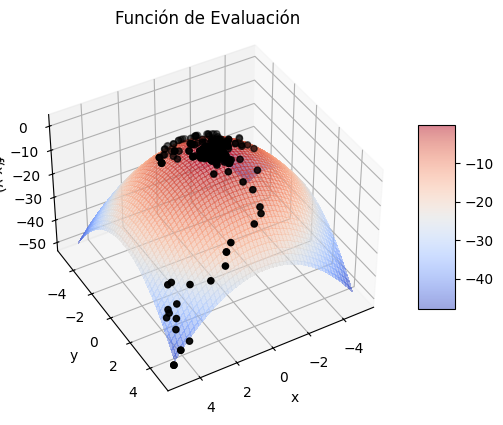

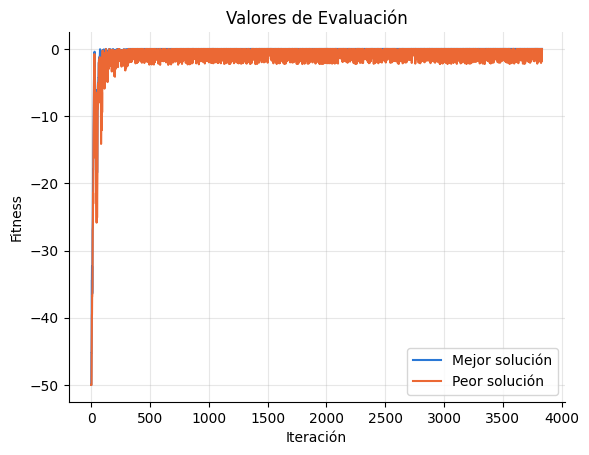

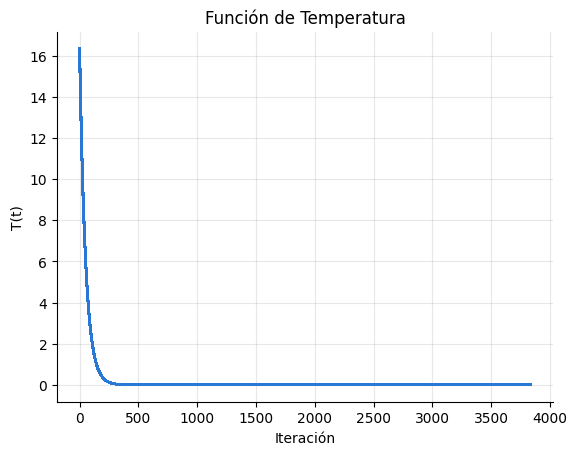

In [60]:
def f(X_vars):
    return -sum( [xi**2 for xi in X_vars] )

bounds_F = [(-5,5), (-5,5)]
optimos_F = [(0.0, 0.0)]

# punto inicial en una de las esquinas
x0 = [row[1] for row in bounds_F]

### COMPLETADO ####
max_eps = 1.5                                   # tamaño máximo del paso
cant_iterac = 1000                               # iteraciones sin mejora para terminar
T0, dF = estimarT0(f, bounds_F, max_eps)        # temperatura inicial (criterio del 80 %)
mu = calcularMu(T0, N=500)                      # coeficiente de enfriamiento (T llega a 0.001 en 500 iteraciones)
print(f"Empeoramiento promedio = {dF:.3f}  ->  T0 = {T0:.3f},  mu = {mu:.5f}")
###

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = SimulatedAnnealing(
    f, x0, max_eps, bounds_F, cant_iterac, T0, mu, verbose=False)
print("-----")
print("Solución: {0}".format([round(v, 4) for v in X_mejor]))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))
graficarCaminata(f, Trace_X_mejor, bounds_F, 0.1)
graficarEvolucionFitness(Trace_f)
graficarTemperatura(T0, mu, len(Trace_f))
params_F = (max_eps, cant_iterac, T0, mu)  # se guardan para la validación y el resumen

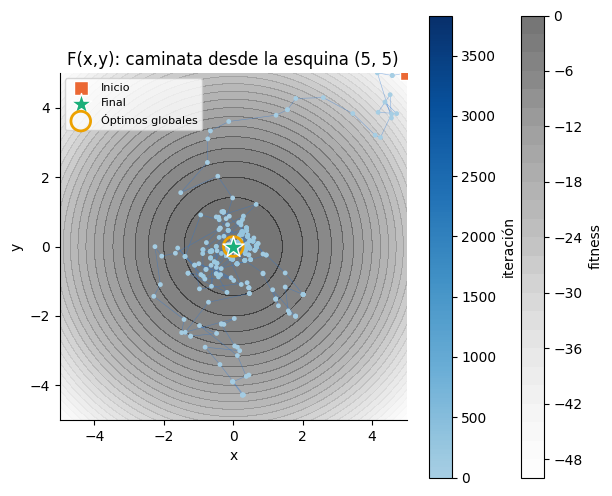

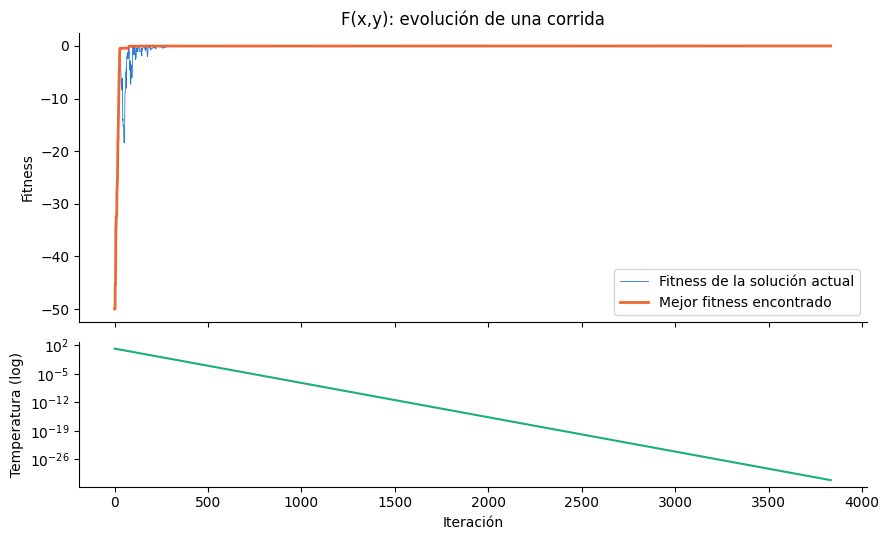

In [61]:
graficarCaminataContorno(f, Trace_X_mejor, bounds_F, optimos_F, 'F(x,y): caminata desde la esquina (5, 5)')
graficarEvolucionCompleta(f, Trace_X_mejor, T0, mu, 'F(x,y): evolución de una corrida')

In [62]:
fin_F, it_F, ex_F = validar(f, bounds_F, optimos_F, *params_F)

Corridas: 100 | Éxito (2 decimales): 97% | En la cuenca del óptimo global: 100%
Iteraciones: mediana 2896, mín 1628, máx 5504


In [63]:
# Resumen individual: Caso 1 (Función F)
print(f"{'Función':10s}{'max_eps':>9s}{'cant_iterac':>13s}{'T0':>8s}{'mu':>10s}{'Éxito':>8s}{'Iter. (mediana)':>17s}")
print(f"{'F':10s}{params_F[0]:9.1f}{params_F[1]:13d}{params_F[2]:8.3f}{params_F[3]:10.5f}{ex_F:8.0%}{int(np.median(it_F)):17d}")

Función     max_eps  cant_iterac      T0        mu   Éxito  Iter. (mediana)
F               1.5         1000  16.321   0.01940     97%             2896


**Conclusiones.** Desde la esquina el algoritmo llegó a $(-0.0003,\ -0.0006)$, es decir, al máximo con 2 decimales, en 3833 iteraciones. En el gráfico de evolución se ve que el fitness sube de −50 a casi 0 en apenas unas decenas de iteraciones, gracias al paso grande, y que todo el resto de la corrida se usa para ganar precisión. Mientras la temperatura es alta, la solución actual a veces empeora, pero la mejor encontrada nunca baja. En la validación, el 97 % de las corridas encontró el máximo con 2 decimales y el 100 % terminó cerca de él, con una mediana de 2896 iteraciones. Las pocas que fallaron llegaron al centro pero cortaron antes de lograr la precisión. Al ser una función con un solo máximo, la temperatura no es realmente necesaria acá: más adelante vemos que hill climbing también funciona.

### Caso 2: $g(x) = -0.01x^2 - \cos(2x)$, con $x \in [-4\pi, 4\pi]$

Primero graficamos la función para ver dónde están los óptimos.

Óptimos locales de g (x, g(x)):
   x = -10.9408   g = -0.2030
   x =  -7.8149   g = 0.3862
   x =  -4.6889   g = 0.7790
   x =  -1.5630   g = 0.9754
   x =   1.5630   g = 0.9754
   x =   4.6889   g = 0.7790
   x =   7.8149   g = 0.3862
   x =  10.9408   g = -0.2030

Óptimos globales: x = ±1.5630  (g = 0.9754)


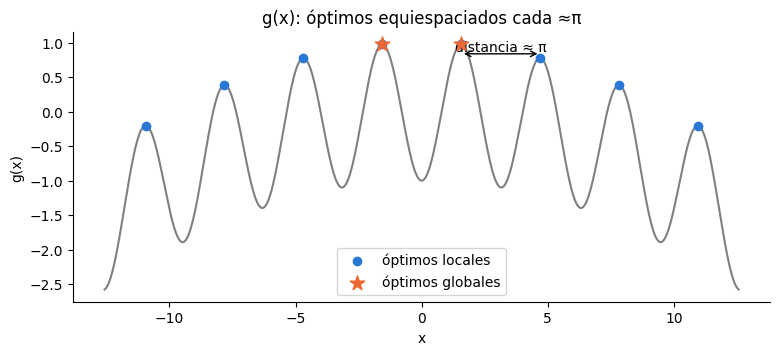

In [64]:
def g(X_vars):
    return -0.01 * sum([xi**2 for xi in X_vars]) - sum([math.cos(2*xi) for xi in X_vars])

# Óptimos locales: se ubican numéricamente con búsqueda fina alrededor de cada pico
xs = np.linspace(-4*np.pi, 4*np.pi, 200001)
gx = -0.01*xs**2 - np.cos(2*xs)
picos = [i for i in range(1, len(xs)-1) if gx[i] > gx[i-1] and gx[i] > gx[i+1]]
print("Óptimos locales de g (x, g(x)):")
for i in picos:
    print(f"   x = {xs[i]:8.4f}   g = {gx[i]:.4f}")
X_STAR = xs[picos][np.argmax(gx[picos])]; X_STAR = abs(X_STAR)
print(f"\nÓptimos globales: x = ±{X_STAR:.4f}  (g = {gx.max():.4f})")

plt.figure(figsize=(9, 3.5))
plt.plot(xs, gx, color='gray')
plt.scatter(xs[picos], gx[picos], color=C[0], zorder=3, label='óptimos locales')
plt.scatter([X_STAR, -X_STAR], [gx.max()]*2, color=C[1], s=120, marker='*', zorder=4, label='óptimos globales')
plt.annotate('', xy=(X_STAR + np.pi, 0.84), xytext=(X_STAR, 0.84), arrowprops=dict(arrowstyle='<->'))
plt.text(X_STAR + np.pi/2, 0.88, 'distancia ≈ π', ha='center')
plt.title('g(x): óptimos equiespaciados cada ≈π'); plt.xlabel('x'); plt.ylabel('g(x)'); plt.legend(loc='lower center')
plt.show()

La función tiene 8 óptimos locales separados por aproximadamente π. Los dos globales están en $x \approx \pm 1.563$ (no exactamente en $\pm\pi/2$, porque el término $-0.01x^2$ los corre un poco hacia el centro). El segundo mejor pico vale 0.779, apenas 0.2 menos que el global, pero para pasar de uno al otro hay que bajar un valle de casi 2 unidades. Eso es lo que hace difícil este caso.

Por eso elegimos `max_eps = 3.2`, apenas más que la distancia entre picos: así el algoritmo puede saltar de un pico al siguiente en un solo paso. No usamos un paso más grande porque cuanto más largo es el paso, más intentos hacen falta para afinar los decimales. Con `cant_iterac = 800` le damos la paciencia necesaria para llegar a los 2 decimales, y la temperatura baja hasta 0.001 en 1000 iteraciones.

Empeoramiento promedio = 0.867  ->  T0 = 3.887,  mu = 0.00827
-----
Solución: [1.562]
Fitness: 0.9754466864023619
Iteraciones: 3006


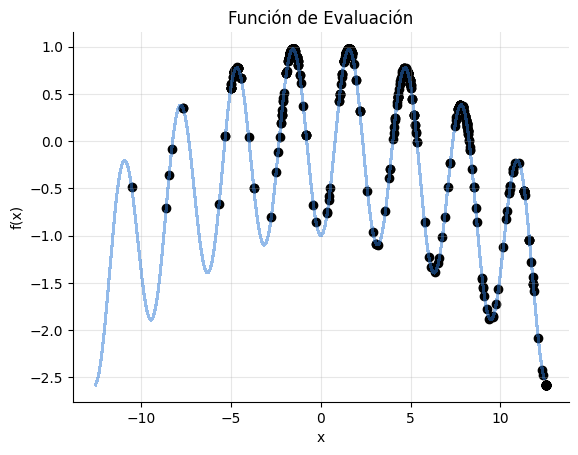

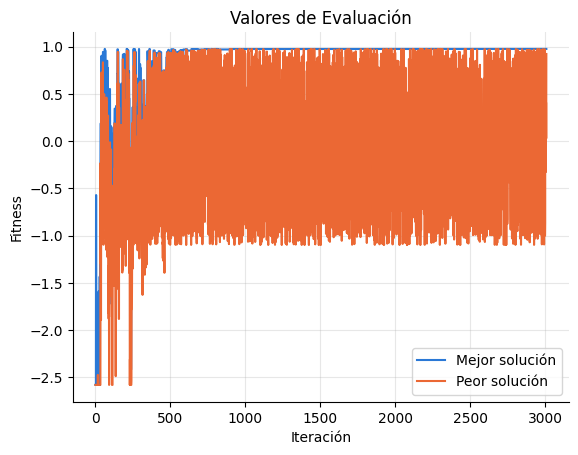

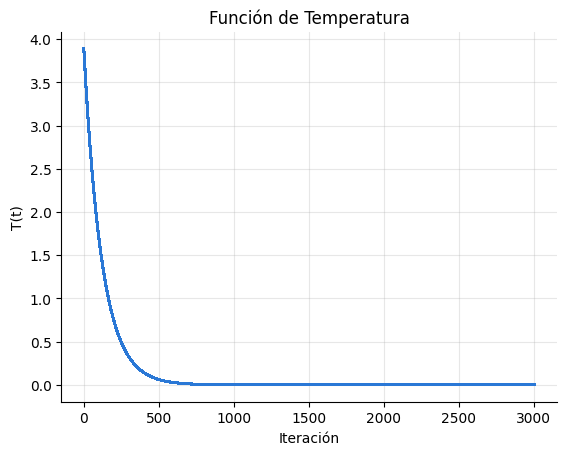

In [65]:
bounds_g = [(-4*math.pi, 4*math.pi)]
optimos_g = [(X_STAR,), (-X_STAR,)]

# punto inicial en una de las esquinas
x0 = [row[1] for row in bounds_g]

### COMPLETADO ####
max_eps = 3.2
cant_iterac = 800
T0, dF = estimarT0(g, bounds_g, max_eps)
mu = calcularMu(T0, N=1000)   # T llega a 0.001 en 1000 iteraciones
print(f"Empeoramiento promedio = {dF:.3f}  ->  T0 = {T0:.3f},  mu = {mu:.5f}")
###

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = SimulatedAnnealing(
    g, x0, max_eps, bounds_g, cant_iterac, T0, mu, verbose=False)
print("-----")
print("Solución: {0}".format([round(v, 4) for v in X_mejor]))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))
graficarCaminata(g, Trace_X_mejor, bounds_g, 0.1)
graficarEvolucionFitness(Trace_f)
graficarTemperatura(T0, mu, len(Trace_f))
params_g = (max_eps, cant_iterac, T0, mu)  # se guardan para la validación y el resumen

El gráfico anterior superpone miles de puntos. Es más claro mirar la posición de la solución en cada iteración:

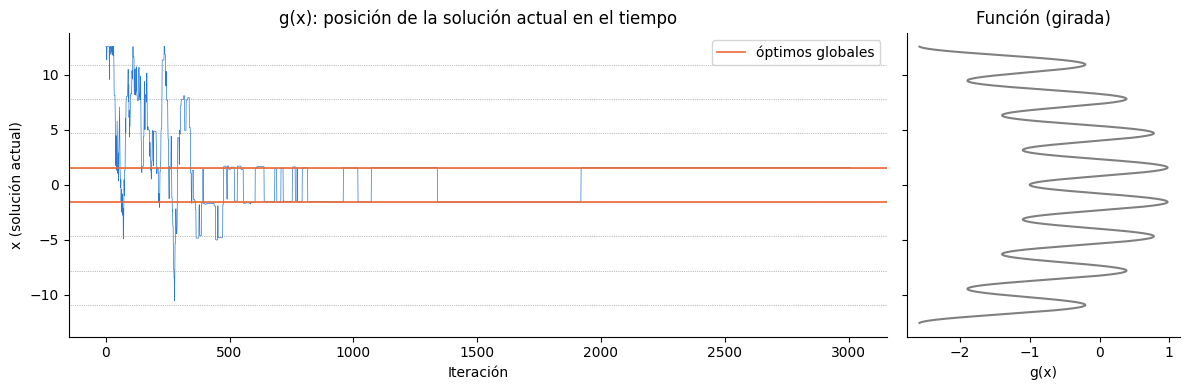

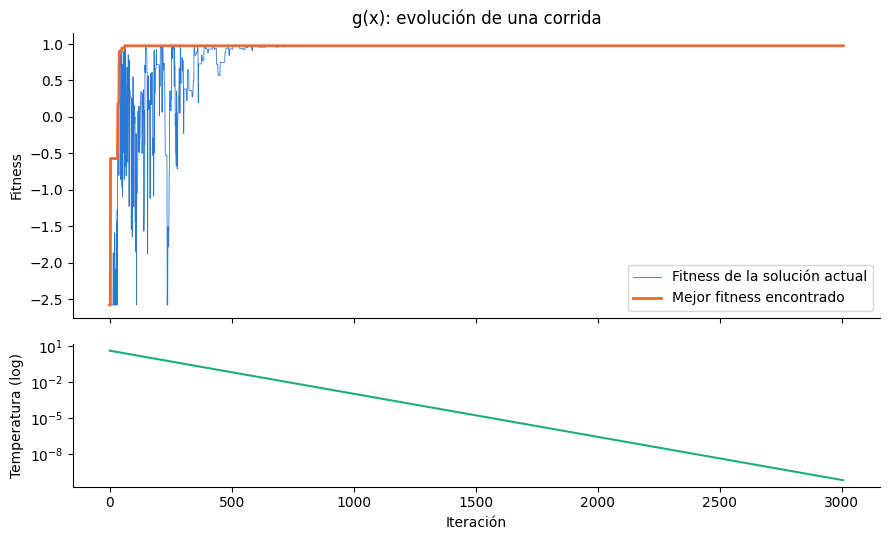

In [66]:
pos = [x[0] for x in Trace_X_mejor]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [3, 1]}, sharey=True)
a1.plot(pos, lw=0.5, color=C[0])
for xp in xs[picos]:
    a1.axhline(xp, color='gray', lw=0.5, ls=':')
a1.axhline(X_STAR, color=C[1], lw=1.2, label='óptimos globales'); a1.axhline(-X_STAR, color=C[1], lw=1.2)
a1.set_xlabel('Iteración'); a1.set_ylabel('x (solución actual)'); a1.legend(loc='upper right')
a1.set_title('g(x): posición de la solución actual en el tiempo')
a2.plot(gx, xs, color='gray'); a2.set_xlabel('g(x)'); a2.set_title('Función (girada)')
plt.tight_layout(); plt.show()
graficarEvolucionCompleta(g, Trace_X_mejor, T0, mu, 'g(x): evolución de una corrida')

Corridas: 100 | Éxito (2 decimales): 96% | En la cuenca del óptimo global: 100%
Iteraciones: mediana 2545, mín 1761, máx 3848


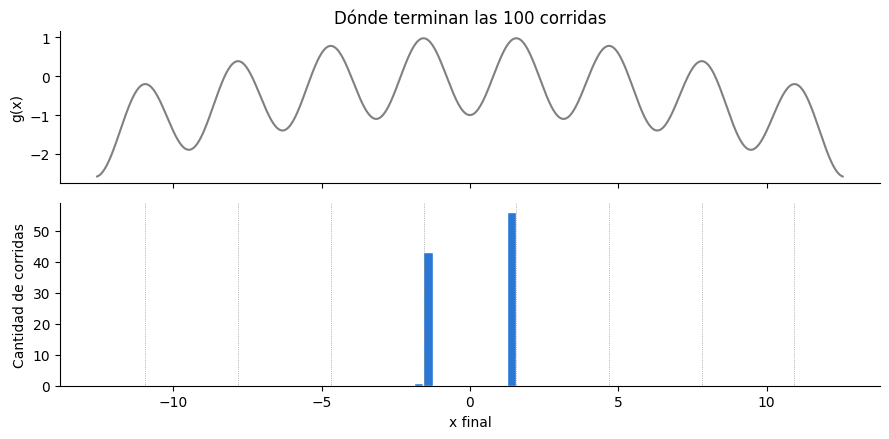

In [67]:
fin_g, it_g, ex_g = validar(g, bounds_g, optimos_g, *params_g)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True, gridspec_kw={'height_ratios': [1, 1.2]})
a1.plot(xs, gx, color='gray'); a1.set_ylabel('g(x)'); a1.set_title('Dónde terminan las 100 corridas')
a2.hist(fin_g[:, 0], bins=np.linspace(-4*np.pi, 4*np.pi, 81), color=C[0], edgecolor='white')
for xp in xs[picos]: a2.axvline(xp, color='gray', lw=0.5, ls=':')
a2.set_ylabel('Cantidad de corridas'); a2.set_xlabel('x final'); plt.tight_layout(); plt.show()

In [68]:
# Resumen individual: Caso 2 (Función g)
print(f"{'Función':10s}{'max_eps':>9s}{'cant_iterac':>13s}{'T0':>8s}{'mu':>10s}{'Éxito':>8s}{'Iter. (mediana)':>17s}")
print(f"{'g':10s}{params_g[0]:9.1f}{params_g[1]:13d}{params_g[2]:8.3f}{params_g[3]:10.5f}{ex_g:8.0%}{int(np.median(it_g)):17d}")

Función     max_eps  cant_iterac      T0        mu   Éxito  Iter. (mediana)
g               3.2          800   3.887   0.00827     96%             2545


**Conclusiones.** Desde $x = 4\pi$ el algoritmo llegó a $x = 1.562$, uno de los dos óptimos globales, en 3006 iteraciones. El gráfico de posición muestra bien cómo funciona: durante las primeras 400 iteraciones, con temperatura alta, salta entre casi todos los picos; después queda sólo entre los dos globales, y a partir de las 2000 iteraciones se dedica a afinar la posición. En la validación, el 96 % de las corridas llegó a un óptimo global con 2 decimales y el 100 % terminó en el pico correcto: las que fallaron se detuvieron antes de lograr la precisión. Las corridas se reparten entre $+1.563$ y $-1.563$, que son igual de buenos. La mediana fue de 2545 iteraciones.

### Caso 3: $G(x,y) = -0.01(x^2+y^2) - \cos(2x) - \cos(2y)$, con $x, y \in [-4\pi, 4\pi]$

$G$ es la suma de $g(x)$ y $g(y)$, así que tiene 8 × 8 = 64 óptimos locales y 4 globales, en $(\pm 1.563, \pm 1.563)$. Elegimos `max_eps = 4`, más grande que la distancia entre picos (≈ π), para que pueda saltar de un pico a otro con facilidad en las dos direcciones. Como hay muchos más óptimos que en $g$, enfriamos más despacio ($N = 2000$). Además subimos `cant_iterac` a 4000, porque en dos dimensiones es mucho más difícil afinar: cerca del óptimo, con un paso tan grande, casi todos los intentos caen lejos o en una dirección que no mejora.

Empeoramiento promedio = 1.112  ->  T0 = 4.983,  mu = 0.00426
-----
Solución: [-1.5633, -1.5622]
Fitness: 1.9508961778459244
Iteraciones: 8809


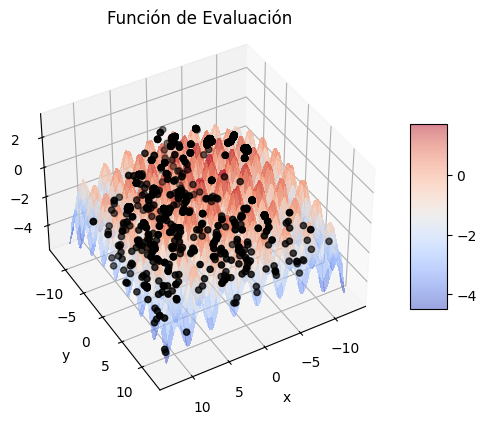

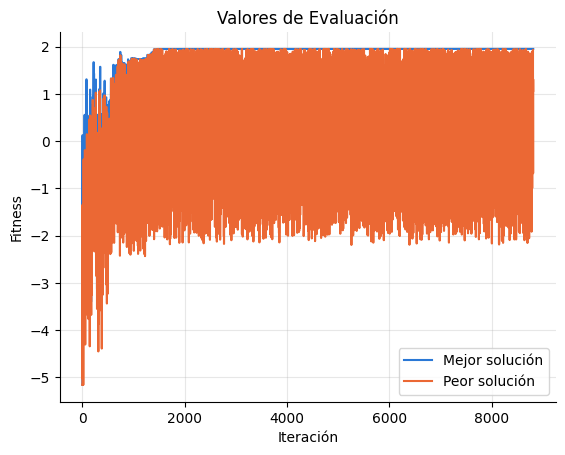

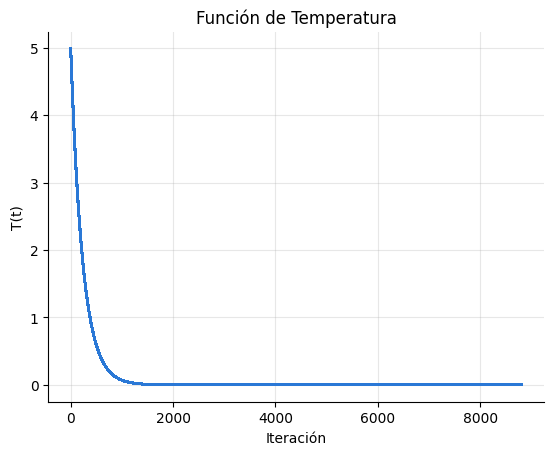

In [102]:
bounds_G = [(-4*math.pi, 4*math.pi) for i in range (2)]
optimos_G = [(sx*X_STAR, sy*X_STAR) for sx in (1, -1) for sy in (1, -1)]

# punto inicial en una de las esquinas
x0 = [row[1] for row in bounds_G]

### COMPLETADO ####
max_eps = 4
cant_iterac = 4000
T0, dF = estimarT0(g, bounds_G, max_eps)
mu = calcularMu(T0, N=2000)   # T llega a 0.001 en 2000 iteraciones
print(f"Empeoramiento promedio = {dF:.3f}  ->  T0 = {T0:.3f},  mu = {mu:.5f}")
###

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = SimulatedAnnealing(
    g, x0, max_eps, bounds_G, cant_iterac, T0, mu, verbose=False)
print("-----")
print("Solución: {0}".format([round(v, 4) for v in X_mejor]))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))
graficarCaminata(g, Trace_X_mejor, bounds_G, 0.1)
graficarEvolucionFitness(Trace_f)
graficarTemperatura(T0, mu, len(Trace_f))
params_G = (max_eps, cant_iterac, T0, mu)  # se guardan para la validación y el resumen

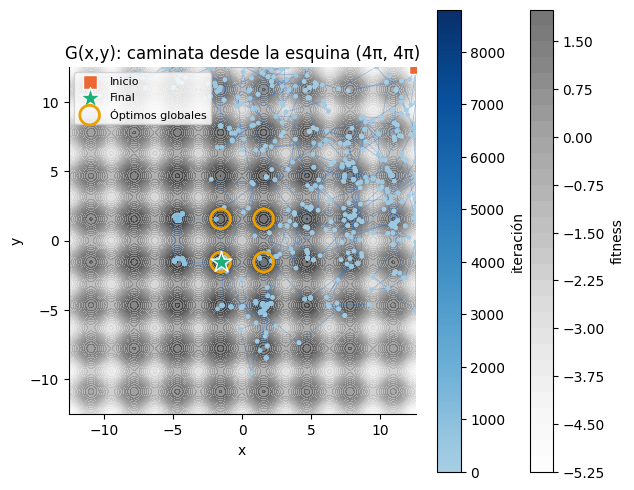

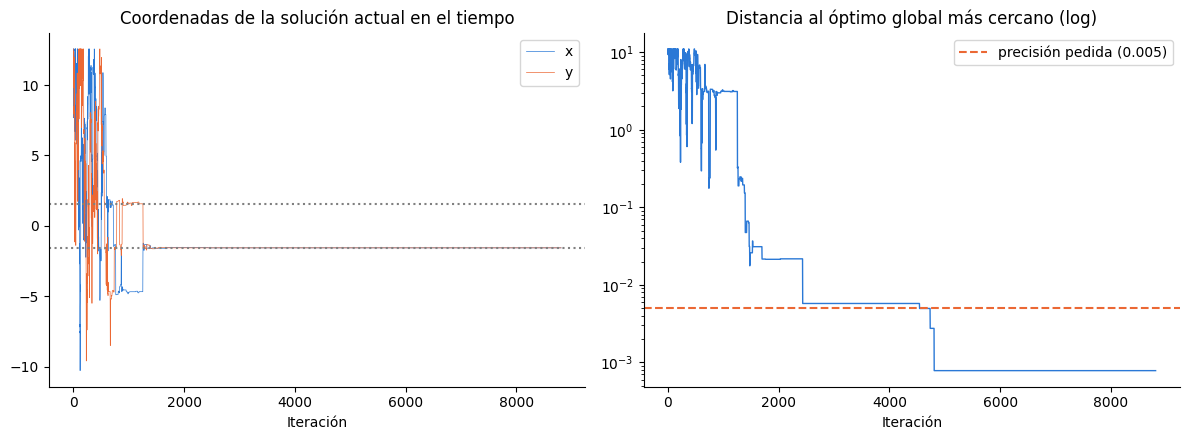

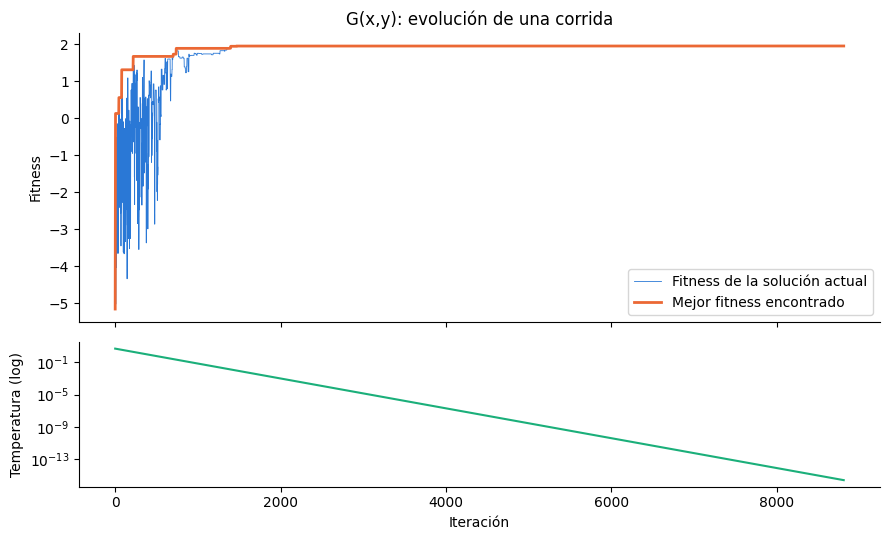

In [103]:
graficarCaminataContorno(g, Trace_X_mejor, bounds_G, optimos_G, 'G(x,y): caminata desde la esquina (4π, 4π)')
# Coordenadas en el tiempo y error respecto del óptimo (escala log) para ver la etapa de ajuste fino
s = np.array(Trace_X_mejor)
err = np.min([np.max(np.abs(s - np.array(o)), axis=1) for o in optimos_G], axis=0)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(s[:, 0], lw=0.5, label='x'); ax[0].plot(s[:, 1], lw=0.5, label='y')
ax[0].axhline(X_STAR, color='gray', ls=':'); ax[0].axhline(-X_STAR, color='gray', ls=':')
ax[0].set_title('Coordenadas de la solución actual en el tiempo'); ax[0].set_xlabel('Iteración'); ax[0].legend()
ax[1].plot(err, lw=1, color=C[0])
ax[1].set_yscale('log'); ax[1].axhline(0.005, color=C[1], ls='--', label='precisión pedida (0.005)')
ax[1].set_title('Distancia al óptimo global más cercano (log)'); ax[1].set_xlabel('Iteración'); ax[1].legend()
plt.tight_layout(); plt.show()
graficarEvolucionCompleta(g, Trace_X_mejor, T0, mu, 'G(x,y): evolución de una corrida')

Corridas: 100 | Éxito (2 decimales): 99% | En la cuenca del óptimo global: 100%
Iteraciones: mediana 10792, mín 6474, máx 27408


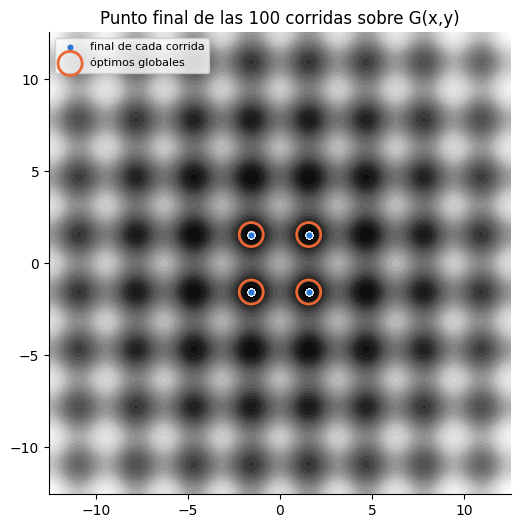

Corridas por óptimo global (signo x, signo y): {(1, 1): 33, (1, -1): 22, (-1, 1): 19, (-1, -1): 26}


In [104]:
fin_G, it_G, ex_G = validar(g, bounds_G, optimos_G, *params_G)
xx = np.linspace(-4*np.pi, 4*np.pi, 300); XX, YY = np.meshgrid(xx, xx)
ZZ = -0.01*(XX**2+YY**2) - np.cos(2*XX) - np.cos(2*YY)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contourf(XX, YY, ZZ, levels=30, cmap='Greys')
ax.scatter(fin_G[:, 0], fin_G[:, 1], color=C[0], s=25, edgecolors='white', lw=0.5, label='final de cada corrida')
o = np.array(optimos_G)
ax.scatter(o[:, 0], o[:, 1], facecolors='none', edgecolors=C[1], s=300, lw=2, label='óptimos globales')
ax.set_aspect('equal'); ax.legend(loc='upper left', fontsize=8); ax.grid(False)
ax.set_title('Punto final de las 100 corridas sobre G(x,y)'); plt.show()
cuad = {(sx, sy): int(np.sum((np.sign(fin_G[:,0])==sx) & (np.sign(fin_G[:,1])==sy))) for sx in (1,-1) for sy in (1,-1)}
print("Corridas por óptimo global (signo x, signo y):", cuad)

In [106]:
# Resumen individual: Caso 3 (Función G)
print(f"{'Función':10s}{'max_eps':>9s}{'cant_iterac':>13s}{'T0':>8s}{'mu':>10s}{'Éxito':>8s}{'Iter. (mediana)':>17s}")
print(f"{'G':10s}{params_G[0]:9.1f}{params_G[1]:13d}{params_G[2]:8.3f}{params_G[3]:10.5f}{ex_G:8.0%}{int(np.median(it_G)):17d}")

Función     max_eps  cant_iterac      T0        mu   Éxito  Iter. (mediana)
G               4.0         4000   4.983   0.00426     99%            10792


**Conclusiones.** Desde la esquina $(4\pi, 4\pi)$ el algoritmo llegó a $(-1.5633,\ -1.5622)$, uno de los cuatro óptimos globales, en 8809 iteraciones. En el gráfico de coordenadas se ve que $x$ e $y$ saltan por todo el dominio al principio y quedan fijas en $\pm 1.56$ cerca de la iteración 1300. En el de la distancia al óptimo se ve que encontrar el pico correcto llevó unas 1300 iteraciones, pero bajar de 0.005 de error recién ocurrió cerca de la 4800: la mayor parte del tiempo se usa para ganar decimales. En la validación, el 99 % de las corridas llegó al óptimo con 2 decimales y el 100 % terminó en el pico correcto. Las corridas se reparten de forma pareja entre los 4 óptimos globales (33, 22, 19 y 26), como es de esperar por la simetría de la función. Es el caso más difícil de los tres y el que más iteraciones necesita: 10 792 de mediana.

## Análisis adicionales

Para estos análisis usamos una copia del algoritmo que además registra la temperatura y si en cada iteración se propuso o se aceptó una solución peor. Primero comprobamos que da exactamente el mismo resultado que `SimulatedAnnealing`.

In [17]:
def SA_ext(fitness, x0, max_eps, bounds, cant_iterac, T0, mu):
    """Mismo algoritmo que SimulatedAnnealing, pero guarda T y las aceptaciones de cada iteración."""
    X_act = list(x0); f_act = fitness(X_act)
    it = cnt = 0; hist = {'T': [], 'peor': [], 'acepta': []}
    while cnt <= cant_iterac:
        T = temperaturaSA(it, T0, mu)
        X, _ = puntoExploracion(X_act, max_eps)
        X = [min(max(xi, b[0]), b[1]) for xi, b in zip(X, bounds)]
        fX = fitness(X)
        peor = acepta = False
        if fX >= f_act:
            X_act, f_act, cnt = X, fX, 0
        else:
            cnt += 1; peor = True
            if random.random() < probabilidadSA(fX, f_act, T):
                X_act, f_act, acepta = X, fX, True
        hist['T'].append(T); hist['peor'].append(peor); hist['acepta'].append(acepta)
        it += 1
    return X_act, f_act, it, hist

# Partiendo del mismo estado del generador aleatorio, las dos versiones tienen que dar el mismo resultado
estado = random.getstate()
a = SimulatedAnnealing(g, [5.0, -3.0], params_G[0], bounds_G, *params_G[1:], verbose=False)
random.setstate(estado)
b = SA_ext(g, [5.0, -3.0], params_G[0], bounds_G, *params_G[1:])
assert a[0] == b[0] and len(a[3]) - 1 == b[2]
print("Mismo resultado:", a[0] == b[0])

def tasa(fitness, bounds, optimos, max_eps, cant_iterac, T0, mu, N=40, tol=0.005):
    """Porcentaje de éxito, porcentaje en el pico correcto e iteraciones promedio en N corridas."""
    ex = cu = its = 0
    for _ in range(N):
        x0 = [random.uniform(*b) for b in bounds]
        X, _, it, _ = SA_ext(fitness, x0, max_eps, bounds, cant_iterac, T0, mu)
        err = min(max(abs(a - b) for a, b in zip(X, o)) for o in optimos)
        ex += err < tol; cu += err < 0.5; its += it
    return ex / N, cu / N, its / N

Mismo resultado: True


### A. ¿Qué aporta la temperatura?

Comparamos Simulated Annealing con hill climbing, que es el mismo algoritmo con temperatura prácticamente cero (nunca acepta soluciones peores). Probamos distintos tamaños de paso, con 40 corridas desde puntos al azar para cada uno, y medimos cuántas terminan en el óptimo global. Lo hicimos para ver si los pasos que elegimos para $g$ (3.2) y $G$ (4) estaban justificados y qué parte del resultado se debe realmente a la temperatura.

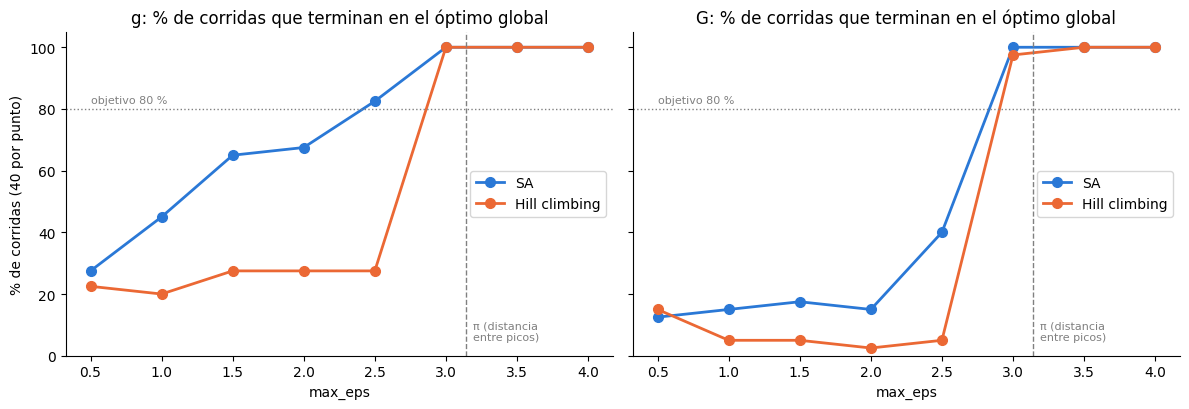

       max_eps    0.5      1    1.5      2    2.5      3    3.5      4
g           SA    28%    45%    65%    68%    82%   100%   100%   100%
g        Hill     22%    20%    28%    28%    28%   100%   100%   100%
G           SA    12%    15%    18%    15%    40%   100%   100%   100%
G        Hill     15%     5%     5%     2%     5%    98%   100%   100%


In [107]:
eps_list = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]
resA = {}
for nombre, bnds, opts in [('g', bounds_g, optimos_g), ('G', bounds_G, optimos_G)]:
    for alg, T0_, mu_ in [('SA', 2.0, 0.002), ('Hill climbing', 1e-9, 0.002)]:
        resA[(nombre, alg)] = [tasa(g, bnds, opts, e, 1500, T0_, mu_) for e in eps_list]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, nombre in zip(axs, ['g', 'G']):
    for k, alg in enumerate(['SA', 'Hill climbing']):
        cu = [r[1] * 100 for r in resA[(nombre, alg)]]
        ax.plot(eps_list, cu, '-o', lw=2, ms=7, color=C[k], label=alg)
    ax.axvline(np.pi, color='gray', ls='--', lw=1); ax.text(np.pi + 0.05, 5, 'π (distancia\nentre picos)', fontsize=8, color='gray')
    ax.axhline(80, color='gray', ls=':', lw=1); ax.text(0.5, 82, 'objetivo 80 %', fontsize=8, color='gray')
    ax.set_title(f'{nombre}: % de corridas que terminan en el óptimo global')
    ax.set_xlabel('max_eps'); ax.set_ylim(0, 105); ax.legend(loc='center right')
axs[0].set_ylabel('% de corridas (40 por punto)')
plt.tight_layout(); plt.show()
print(f"{'':6s}{'max_eps':>8s}" + ''.join(f'{e:>7}' for e in eps_list))
for (nombre, alg), r in resA.items():
    print(f"{nombre:3s}{alg[:5]:>11s}" + ''.join(f'{x[1]:7.0%}' for x in r))

**Conclusiones.** Con pasos de 3 o más, los dos métodos encuentran el óptimo global casi siempre (entre 98 % y 100 %). Tiene sentido: los picos están separados por π, y con un paso de ese tamaño se puede saltar directamente al pico global, sin necesidad de aceptar soluciones peores. Con pasos más chicos la diferencia es clara: con `max_eps = 2`, en $g$ Simulated Annealing llegó el 68 % de las veces y hill climbing sólo el 28 %; en $G$, 15 % contra 2 %. Sin temperatura, el algoritmo queda atrapado en el primer pico que encuentra; con temperatura puede bajar el valle y pasar al siguiente. Aun así, con pasos chicos no se alcanza el 80 %, y por eso elegimos pasos mayores que π.

### B. ¿Cuántas soluciones peores acepta a medida que se enfría?

En una corrida de $G$ con los parámetros elegidos, medimos qué porcentaje de las soluciones peores fue aceptado en cada tramo de 100 iteraciones. Queríamos ver la transición entre la etapa en la que el algoritmo explora y la etapa en la que sólo mejora, y comprobar si el criterio del 80 % para `T0` funcionó.

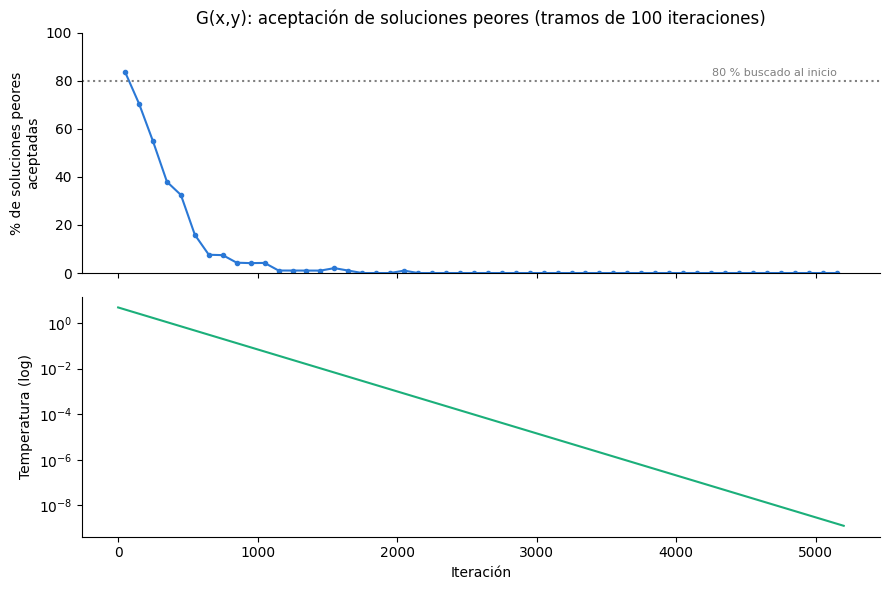

Aceptación en la primera ventana: 84 %   |   en la última: 0.0 %
Baja del 50 % en la iteración ≈350 (T ≈ 1.09); baja del 5 % en ≈850 (T ≈ 0.13)


In [19]:
_, _, nit, h = SA_ext(g, [4*np.pi, 4*np.pi], params_G[0], bounds_G, *params_G[1:])
peor = np.array(h['peor']); acep = np.array(h['acepta']); Tt = np.array(h['T'])
W = 100; nv = len(peor) // W
tasaD = [acep[k*W:(k+1)*W].sum() / max(peor[k*W:(k+1)*W].sum(), 1) * 100 for k in range(nv)]
centros = np.arange(nv) * W + W / 2
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
a1.plot(centros, tasaD, '-o', ms=3, color=C[0])
a1.axhline(80, color='gray', ls=':'); a1.text(centros[-1], 82, '80 % buscado al inicio', ha='right', fontsize=8, color='gray')
a1.set_ylabel('% de soluciones peores\naceptadas'); a1.set_ylim(0, 100)
a1.set_title('G(x,y): aceptación de soluciones peores (tramos de 100 iteraciones)')
a2.plot(Tt, color=C[2]); a2.set_yscale('log'); a2.set_ylabel('Temperatura (log)'); a2.set_xlabel('Iteración')
plt.tight_layout(); plt.show()
print(f"Aceptación en la primera ventana: {tasaD[0]:.0f} %   |   en la última: {tasaD[-1]:.1f} %")
i50 = next(k for k, v in enumerate(tasaD) if v < 50); i5 = next(k for k, v in enumerate(tasaD) if v < 5)
print(f"Baja del 50 % en la iteración ≈{centros[i50]:.0f} (T ≈ {Tt[int(centros[i50])]:.2f}); "
      f"baja del 5 % en ≈{centros[i5]:.0f} (T ≈ {Tt[int(centros[i5])]:.2f})")

**Conclusiones.** En el primer tramo aceptó el 84 % de las soluciones peores, cerca del 80 % que buscábamos, así que el criterio para `T0` funcionó. La aceptación baja del 50 % cerca de la iteración 350 (con $T \approx 1.1$) y del 5 % cerca de la 850 ($T \approx 0.13$); a partir de ahí el algoritmo prácticamente sólo acepta mejoras. Como la corrida completa dura varios miles de iteraciones, la exploración ocupa sólo la primera parte y el resto del tiempo se usa para afinar los decimales.

## Ejercicio 3

**1. ¿Cómo es el mecanismo que usa Simulated Annealing para "escapar" de los óptimos locales?**

Un algoritmo que sólo acepta mejoras se queda atrapado en cuanto llega a un óptimo local, porque todos los puntos vecinos son peores. Simulated Annealing, en cambio, acepta a veces moverse a una solución peor, con probabilidad $p = e^{(f(X_{nuevo}) - f(X_{actual}))/T}$. Esa probabilidad es mayor cuanto menos empeora la solución y cuanto más alta es la temperatura. Al principio, con temperatura alta, acepta casi todo y puede cruzar los valles entre picos. A medida que la temperatura baja, acepta cada vez menos empeoramientos, hasta que se comporta como una búsqueda que sólo mejora y afina el óptimo donde quedó. La idea viene del recocido de metales: si el metal se enfría despacio, sus átomos llegan a una estructura de mínima energía; si se enfría de golpe, quedan en una estructura peor.

En este trabajo también vimos que, cuando el valle entre dos picos es mucho más profundo que la diferencia entre ellos, cruzarlo aceptando empeoramientos es difícil. En ese caso ayuda mucho usar un paso lo suficientemente grande como para saltar el valle.

**2. ¿Qué criterio utilizó para determinar el valor de la temperatura inicial (T0) y el coeficiente de enfriamiento (mu)?**

Para `T0` buscamos que al principio se acepte el 80 % de los movimientos a peor. Estimamos el empeoramiento promedio de 2000 pasos al azar y despejamos $T_0 = -\overline{\Delta f}/\ln 0.8$. Para `mu` elegimos en cuántas iteraciones $N$ debe llegar la temperatura a 0.001, según cuánto hay que explorar en cada función, y despejamos $\mu = \ln(T_0/0.001)/N$. Como el empeoramiento promedio se estima con pasos al azar, los valores cambian levemente en cada ejecución. En la última obtuvimos:

| Función | max_eps | Empeoramiento promedio | T0 | N | mu |
|---|---|---|---|---|---|
| F | 1.5 | 3.642 | 16.32 | 500 | 0.0194 |
| g | 3.2 | 0.867 | 3.89 | 1000 | 0.0083 |
| G | 4 | 1.112 | 4.98 | 2000 | 0.0043 |

$F$ tiene el $T_0$ más alto: aunque su paso no es el más grande, la función cambia mucho entre un punto y otro cerca de las esquinas (vale −50 en $(5,5)$), así que un paso de 1.5 puede empeorar el fitness varias unidades. Después comprobamos los parámetros con 100 corridas desde puntos iniciales al azar, y en el análisis B verificamos que al comienzo se aceptó el 84 % de los empeoramientos, cerca del 80 % buscado.

## Conclusiones generales

Con los parámetros elegidos, los tres casos superan el 80 % pedido desde puntos iniciales al azar. En la última ejecución obtuvimos 97 % en $F$, 96 % en $g$ y 99 % en $G$, y en todos los casos el 100 % de las corridas terminó en el pico correcto. Como no fijamos semillas, al volver a ejecutar el notebook estos porcentajes pueden variar algunos puntos.

Cada caso necesitó parámetros distintos. En $F$, que tiene un solo máximo, no hace falta explorar: con un enfriamiento rápido y suficiente paciencia para afinar alcanzó, con una mediana de 2896 iteraciones. En $g$ y $G$ lo que más influyó fue el tamaño del paso: como los picos están separados por π, un paso mayor permite saltar entre ellos. La temperatura ayuda cuando el paso es chico, pero por sí sola no alcanzó para llegar al 80 %.

También notamos que la mayor parte de las iteraciones se usa para ganar precisión y no para encontrar el pico correcto. Cuanto más grande es el paso, y sobre todo en dos variables, más cuesta afinar los decimales. Por eso $G$, con paso 4 y dos variables, es el que más iteraciones necesita (10 792 de mediana).

Por último, como el algoritmo es aleatorio, no sacamos conclusiones de una sola corrida: cada caso se validó con 100 corridas desde puntos iniciales distintos.